In [1]:
import pandas as pd
import sqlalchemy as db
import matplotlib.pyplot as plt
from sqlalchemy import func, create_engine, case

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
engine = create_engine('sqlite:///titanic.db')

In [4]:
conn = engine.connect()
metadata = db.MetaData()

In [5]:
df.to_sql(
    "titanic",
    con=engine,
    if_exists="replace",
    index=False
)

792

In [6]:
titanic = db.Table(
    'Titanic', metadata, autoload_with=engine
)

In [7]:
survived = db.select(
    func.count(titanic.c.PassengerId).label("Survived"),
).where(
    titanic.c.Survived == 1
).group_by(titanic.c.Survived)

survived_by_sex = db.select(
    titanic.c.Sex.label("Sex"),
    func.count(titanic.c.Sex).label("count")
).where(
    titanic.c.Survived == 1
).group_by(titanic.c.Survived, titanic.c.Sex)

update_query = (
    db.update(titanic)
    .where(titanic.c.Sex == 0)
    .values(Sex="Female")
)

update_query_2 = (
    db.update(titanic)
    .where(titanic.c.Sex == 1)
    .values(Sex="Male")
)

select_result = conn.execute(update_query)
select_result = conn.execute(update_query_2)
select_result = conn.execute(survived_by_sex).mappings().all()

select_result


[{'Sex': 'Female', 'count': 209}, {'Sex': 'Male', 'count': 97}]

In [8]:
survival_rate_by_sex = db.Select(titanic.c.Sex.label("Sex"), func.round(func.avg(titanic.c.Survived)*100, 2).label("Survival_rate")).group_by(titanic.c.Sex)
select_result = conn.execute(survival_rate_by_sex).mappings().all()
select_result

[{'Sex': 'Female', 'Survival_rate': 74.91},
 {'Sex': 'Male', 'Survival_rate': 18.91}]

In [9]:
age_real = titanic.c.Age * 100

age_group = case(
    (age_real < 10, '0-9'),
    (age_real < 20, '10-19'),
    (age_real < 30, '20-29'),
    (age_real < 40, '30-39'),
    (age_real < 50, '40-49'),
    (age_real < 60, '50-59'),
    (age_real < 70, '60-69'),
    (age_real < 80, '70-79'),
    (age_real < 90, '80-89'),
    else_='90+'
).label('age_group')

query = db.select(
    age_group,
    func.count().label('count')
).group_by(age_group).order_by(age_group)

result = conn.execute(query).mappings().all()
result

[{'age_group': '0-9', 'count': 43},
 {'age_group': '10-19', 'count': 28},
 {'age_group': '20-29', 'count': 149},
 {'age_group': '30-39', 'count': 317},
 {'age_group': '40-49', 'count': 107},
 {'age_group': '50-59', 'count': 66},
 {'age_group': '60-69', 'count': 46},
 {'age_group': '70-79', 'count': 24},
 {'age_group': '80-89', 'count': 11},
 {'age_group': '90+', 'count': 1}]

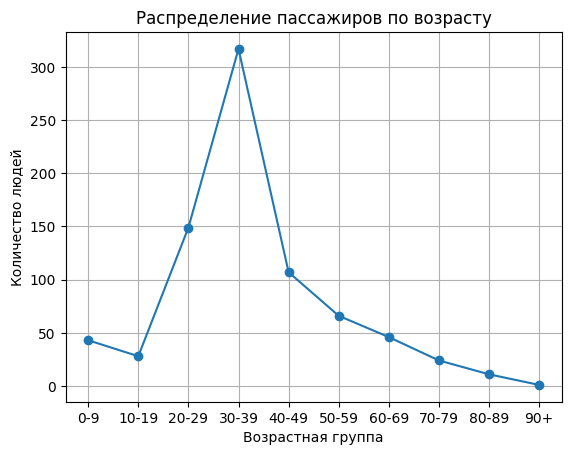

In [10]:
labels = [row['age_group'] for row in result]
counts = [row['count'] for row in result]

plt.plot(labels, counts, marker='o')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество людей')
plt.title('Распределение пассажиров по возрасту')
plt.grid(True)
plt.show()

In [11]:
# Вывод: Большинство пассажиров были в возрасте от 30 до 39 лет, а людей старше 70 было значительно меньше.

In [12]:
query_by_sexes = db.select(
    titanic.c.Sex.label('sex'),
    age_group,
    func.count().label('count')
).group_by(titanic.c.Sex, age_group).order_by(titanic.c.Sex, age_group)

result_by_sexes = conn.execute(query_by_sexes).mappings().all()

female_results = []
male_results = []

for row in result_by_sexes:
    if row['sex'] == 'Female':
        female_results.append(row)
    else:
        male_results.append(row)

female_results

[{'sex': 'Female', 'age_group': '0-9', 'count': 23},
 {'sex': 'Female', 'age_group': '10-19', 'count': 16},
 {'sex': 'Female', 'age_group': '20-29', 'count': 52},
 {'sex': 'Female', 'age_group': '30-39', 'count': 105},
 {'sex': 'Female', 'age_group': '40-49', 'count': 38},
 {'sex': 'Female', 'age_group': '50-59', 'count': 22},
 {'sex': 'Female', 'age_group': '60-69', 'count': 16},
 {'sex': 'Female', 'age_group': '70-79', 'count': 7}]

In [13]:
male_results

[{'sex': 'Male', 'age_group': '0-9', 'count': 20},
 {'sex': 'Male', 'age_group': '10-19', 'count': 12},
 {'sex': 'Male', 'age_group': '20-29', 'count': 97},
 {'sex': 'Male', 'age_group': '30-39', 'count': 212},
 {'sex': 'Male', 'age_group': '40-49', 'count': 69},
 {'sex': 'Male', 'age_group': '50-59', 'count': 44},
 {'sex': 'Male', 'age_group': '60-69', 'count': 30},
 {'sex': 'Male', 'age_group': '70-79', 'count': 17},
 {'sex': 'Male', 'age_group': '80-89', 'count': 11},
 {'sex': 'Male', 'age_group': '90+', 'count': 1}]

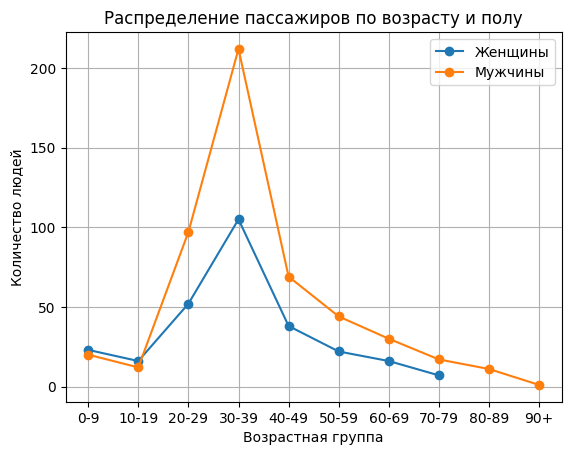

In [14]:
female_labels = [row['age_group'] for row in female_results]
female_counts = [row['count'] for row in female_results]

male_labels = [row['age_group'] for row in male_results]
male_counts = [row['count'] for row in male_results]

plt.plot(female_labels, female_counts, marker='o', label='Женщины')
plt.plot(male_labels, male_counts, marker='o', label='Мужчины')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество людей')
plt.title('Распределение пассажиров по возрасту и полу')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Вывод: Наибольшее количество пассажиров как женского, так и мужского пола
# приходится на возрастную группу 30–39 лет, причем мужчин в этой категории
# почти в 2 раза больше, чем женщин. В целом мужчины преобладают практически
# во всех возрастных группах. После 40 лет количество пассажиров постепенно снижается,
# а среди людей старше 70 лет пассажиров уже значительно меньше.

In [30]:
query_survived = db.select(
    titanic.c.Sex.label('sex'),
    age_group,
    func.count().label('count')
).where(titanic.c.Survived == 1).group_by(titanic.c.Sex, age_group).order_by(titanic.c.Sex, age_group)

result_survived = conn.execute(query_survived).mappings().all()

female_survived = []
male_survived = []

for row in result_survived:
    if row['sex'] == 'Female':
        female_survived.append(row)
    else:
        male_survived.append(row)

age_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']

female_survived_counts = [0] * len(age_labels)
male_survived_counts = [0] * len(age_labels)

for row in female_survived:
    for i in range(len(age_labels)):
        if row['age_group'] == age_labels[i]:
            female_survived_counts[i] = row['count']

for row in male_survived:
    for i in range(len(age_labels)):
        if row['age_group'] == age_labels[i]:
            male_survived_counts[i] = row['count']

female_survived_counts


[12, 4, 11, 34, 18, 7, 7, 3, 0, 1]

In [31]:
male_survived_counts

[12, 4, 11, 34, 18, 7, 7, 3, 0, 1]

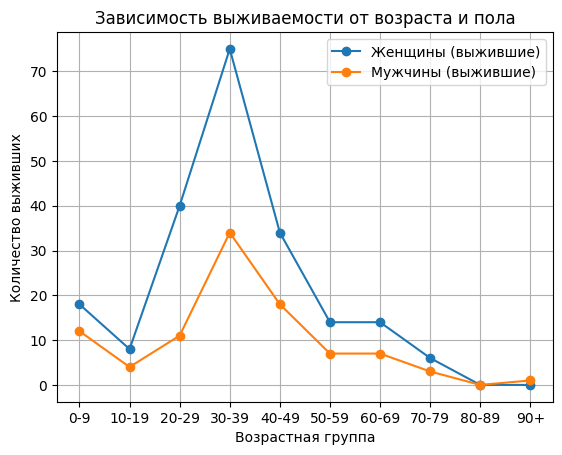

In [28]:
plt.plot(age_labels, female_survived_counts, marker='o', label='Женщины (выжившие)')
plt.plot(age_labels, male_survived_counts, marker='o', label='Мужчины (выжившие)')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество выживших')
plt.title('Зависимость выживаемости от возраста и пола')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Вывод:  среди выживших пассажиров женщин было больше, чем мужчин практически
# во всех возрастных группах. Наибольшее количество выживших приходится на возраст 30–39 лет,
# особенно среди женщин. В старших возрастных категориях количество выживших постепенно
# снижается для обоих полов.